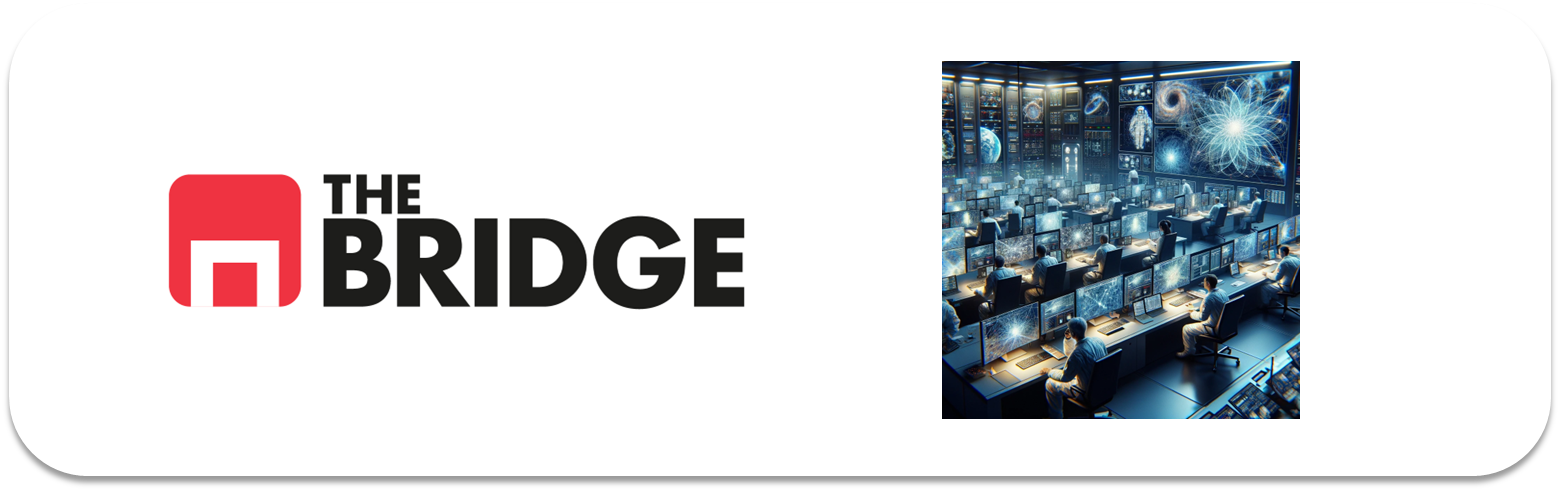

## PRACTICA OBLIGATORIA: **Redes Convolucionales**

* La práctica obligatoria de esta unidad consiste en un ejercicio de construcción de una red convolucional con Keras para la clasificación de imagenes de simpáticos perretes y gatetes. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook.

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Semilla para reproducibilidad
np.random.seed(42)
tf.random.set_seed(42)

# Tamaño al que redimensionaremos todas las imágenes
IMG_SIZE = (96, 96)

import warnings
warnings.filterwarnings('ignore')

### Problema de Negocio y dataset

Una conocida empresa de información inmobiliaria utiliza un CAPTCHA visual de perros y gatos para detectar webscrappings intensivos y ataques de denegación de servicio. Últimamente, ha detectado que su sistema está empezando a flojear, es decir que hay muchos sistemas de detección automática de imágenes que son capaces de detectar que es un perro y un gato y salterse el CAPTCHA antirobots. Por eso nos ha pedido que entrenemos un modelo potente de clasificación que emule a estos sistemas con el objetivo de emplear como fotografías para el CAPTCHA aquellas que no sepa detectar este sistema emulador de chicos malos.  

Pues manos a la obra, tenemos que seleccionar en un conjunto de 1000 imágenes aquellas que peor se le daría clasificar a un potencial sistema anti-CAPTCHA.  

Para ello vamos a emplear un conjunto de train de 4000 imágenes de perretes y gatetes que se encuentran distribuidas en "data" en cuatro directorios "github_train_0",  "github_train_1", "githun_train_2" y "github_train_3". Los datos de las imagenes que tenemos que clasificar y luego seleccionar como las más "difíciles" están en "data" en el directorio "github_test".


### Se pide

1. Crear los datasets X,y de train y test, leyendo las imágenes de los directorios correspondientes (tendrás que leer todas las imágenes de los cuatro directorios para train) y a la vez que se leen adpatar su resolución para que todas tengan un tamaño de 32x32. En este caso puedes adaptar las funciones de los ejercicios de la unidad. NOTA: Ten en cuenta que la clase a la que pertenece en la foto está en el nombre del archivo.

2. Crea un modelo DL basado en redes convolucionales con al menos dos juegos Convolucional-Pooling. Sigue todo el proceso de ML (visualización del dataset, MiniEDA, Construcción del modelo)

3. Entrenar el modelo con un callback de Earlystopping con paciencia la que tengas :-). Muestra su historial de entrenamiento.

4. Evalua el modelo, haz un reporte de clasificacion y muestra la matriz de confianza.

5. Es el momento de seleccionar las imagenes: Selecciona el 10% de imágenes mal clasificadas de una y otra clase que tengan el mayor nivel de confianza de que pertenencían a la clase errónea. Es decir las imágenes de perros clasificadas como gatos y con la probabilidad de ser perror más alta.


### Extra (para hacer en clase)

Repite los pasos 3 a 5 utilizando el generador de imágenes sintéticas o Image Augmentation de Keras. 



### Ejercicio 1

Creación de los datasets `X, y` de train y test, leyendo las imágenes y redimensionándolas a 32x32. La clase (`cat`/`dog`) se extrae del nombre del fichero.

In [24]:
def obtener_label(nombre_fichero):
    """Extrae la etiqueta (0=gato, 1=perro) a partir del nombre del archivo."""
    nombre = nombre_fichero.lower()
    if "cat" in nombre:
        return 0
    elif "dog" in nombre:
        return 1
    else:
        return None


def cargar_imagenes_de_directorio(directorio, size=IMG_SIZE):
    """Lee todas las imágenes de un directorio, las redimensiona y extrae su etiqueta."""
    X, y, filenames = [], [], []
    for fname in sorted(os.listdir(directorio)):
        fpath = os.path.join(directorio, fname)
        if not os.path.isfile(fpath):
            continue
        label = obtener_label(fname)
        if label is None:
            # Si no podemos inferir la clase del nombre, ignoramos el fichero
            continue
        try:
            img = Image.open(fpath).convert("RGB").resize(size)
        except Exception as e:
            print(f"No se pudo leer {fpath}: {e}")
            continue
        X.append(np.array(img))
        y.append(label)
        filenames.append(fname)
    return np.array(X), np.array(y), filenames


def cargar_dataset(directorios, size=IMG_SIZE):
    """Concatena las imágenes/labels de una lista de directorios."""
    X_total, y_total, files_total = [], [], []
    for d in directorios:
        Xd, yd, filesd = cargar_imagenes_de_directorio(d, size=size)
        X_total.append(Xd)
        y_total.append(yd)
        files_total.extend(filesd)
    X_total = np.concatenate(X_total, axis=0)
    y_total = np.concatenate(y_total, axis=0)
    return X_total, y_total, files_total


# Directorios de train (4 particiones) y de test
train_dirs = [
    os.path.join("data/github_train_0"),
    os.path.join("data/github_train_1"),
    os.path.join("data/github_train_2"),
    os.path.join("data/github_train_3"),
]
test_dir = os.path.join("data/github_test")

X_train, y_train, files_train = cargar_dataset(train_dirs)
X_test, y_test, files_test = cargar_dataset([test_dir])

print("Train ->", X_train.shape, y_train.shape)
print("Test  ->", X_test.shape, y_test.shape)

Train -> (4000, 32, 32, 3) (4000,)
Test  -> (1000, 32, 32, 3) (1000,)


### Ejercicio 2

Mini EDA, visualización del dataset y construcción del modelo CNN con al menos dos bloques Convolucional-Pooling.

Distribución de clases en TRAIN (0=gato, 1=perro):
0    2000
1    2000
Name: count, dtype: int64

Distribución de clases en TEST (0=gato, 1=perro):
0    500
1    500
Name: count, dtype: int64


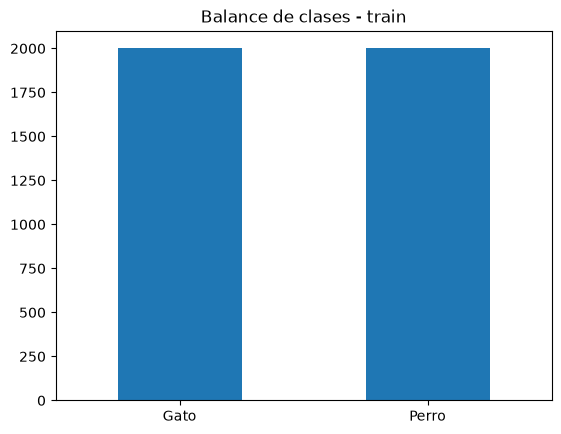

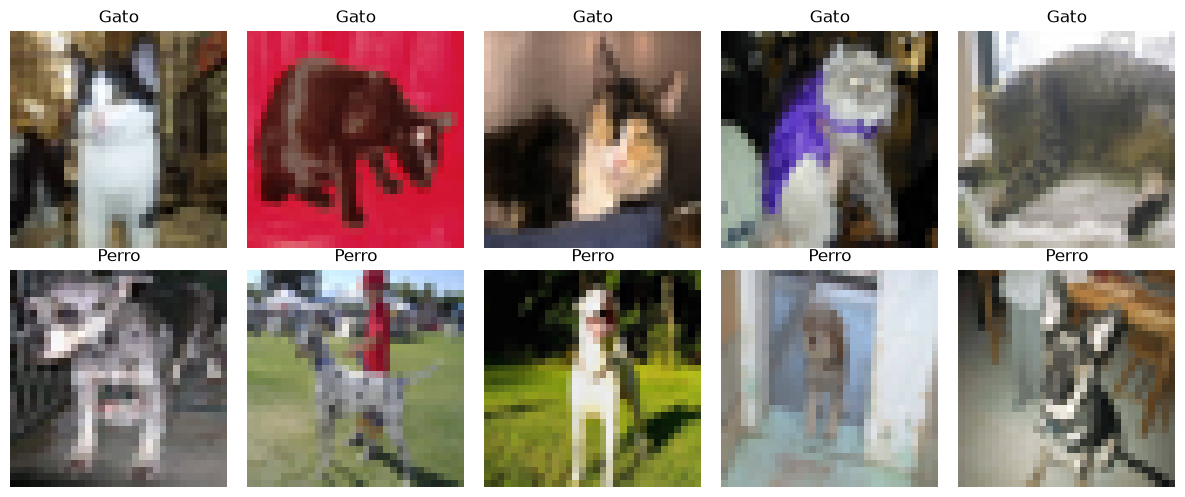

In [25]:
# --- Mini EDA ---

# Balance de clases en train y test
print("Distribución de clases en TRAIN (0=gato, 1=perro):")
print(pd.Series(y_train).value_counts())
print("\nDistribución de clases en TEST (0=gato, 1=perro):")
print(pd.Series(y_test).value_counts())

pd.Series(y_train).value_counts().plot(kind="bar", title="Balance de clases - train")
plt.xticks([0, 1], ["Gato", "Perro"], rotation=0)
plt.show()

# Visualizamos algunas imágenes de ejemplo de cada clase
clases = {0: "Gato", 1: "Perro"}
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for clase in [0, 1]:
    idxs = np.where(y_train == clase)[0][:5]
    for j, idx in enumerate(idxs):
        axes[clase, j].imshow(X_train[idx])
        axes[clase, j].set_title(clases[clase])
        axes[clase, j].axis("off")
plt.tight_layout()
plt.show()


In [26]:
# --- Preprocesado ---

# Normalizamos los píxeles a rango [0, 1]
X_train_norm = X_train.astype("float32") / 255.0
X_test_norm = X_test.astype("float32") / 255.0

# Separamos una partición de validación a partir del train
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_norm, y_train, test_size=0.2, random_state=42, stratify=y_train
)

print("Train:", X_tr.shape, "Val:", X_val.shape, "Test:", X_test_norm.shape)

Train: (3200, 32, 32, 3) Val: (800, 32, 32, 3) Test: (1000, 32, 32, 3)


In [27]:
# --- Construcción del modelo ---

model = Sequential([
    Conv2D(32, (3, 3), activation="relu", padding="same", input_shape=(32, 32, 3)),
    MaxPooling2D((2, 2)),

    Conv2D(64, (3, 3), activation="relu", padding="same"),
    MaxPooling2D((2, 2)),

    Conv2D(128, (3, 3), activation="relu", padding="same"),
    MaxPooling2D((2, 2)),

    Flatten(),
    Dense(128, activation="relu"),
    Dropout(0.5),
    Dense(1, activation="sigmoid"),
])

model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 355,649 (1.36 MB)

 Trainable params: 355,649 (1.36 MB)

 Non-trainable params: 0 (0.00 B)

### Ejercicio 3

Entrenamos el modelo con un callback de `EarlyStopping` y mostramos el historial de entrenamiento.

In [28]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=8,
    restore_best_weights=True,
)

history = model.fit(
    X_tr, y_tr,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1,
)

Epoch 1/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.5231 - loss: 0.6921 - val_accuracy: 0.5213 - val_loss: 0.6960
Epoch 2/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.6053 - loss: 0.6625 - val_accuracy: 0.6137 - val_loss: 0.6719
Epoch 3/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.6578 - loss: 0.6223 - val_accuracy: 0.6700 - val_loss: 0.6019
Epoch 4/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.6956 - loss: 0.5837 - val_accuracy: 0.7075 - val_loss: 0.5676
Epoch 5/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.7259 - loss: 0.5504 - val_accuracy: 0.7200 - val_loss: 0.5420
Epoch 6/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.7472 - loss: 0.5153 - val_accuracy: 0.7287 - val_loss: 0.5328
Epoch 7/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.7741 - loss: 0.4749 - val_accuracy: 0.7450 - val_loss: 0.5249
Epoch 8/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.7875 - loss: 0.4480 - 

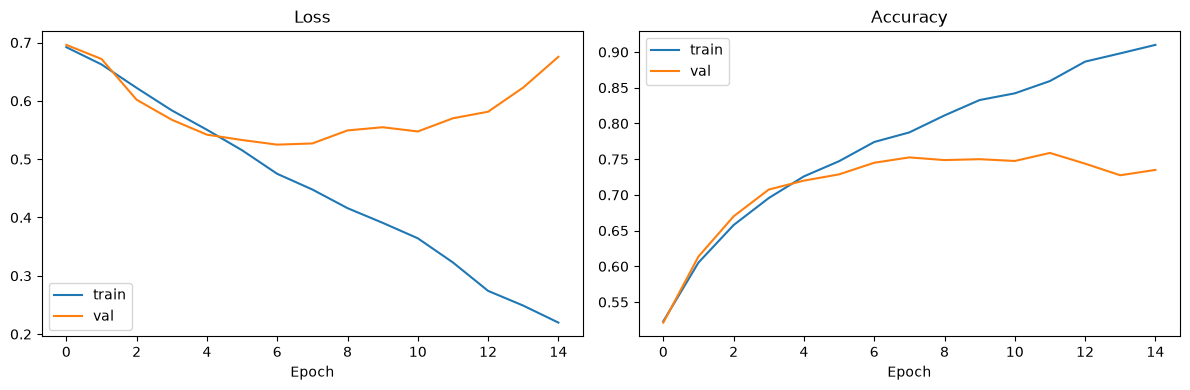

In [29]:
# --- Historial de entrenamiento ---

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history["loss"], label="train")
axes[0].plot(history.history["val_loss"], label="val")
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(history.history["accuracy"], label="train")
axes[1].plot(history.history["val_accuracy"], label="val")
axes[1].set_title("Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].legend()

plt.tight_layout()
plt.show()

### Ejercicio 4

Evaluación del modelo sobre el conjunto de test: reporte de clasificación y matriz de confusión.

Test loss: 0.5215 - Test accuracy: 0.7420

Reporte de clasificación:

              precision    recall  f1-score   support

        Gato       0.74      0.74      0.74       500
       Perro       0.74      0.74      0.74       500

    accuracy                           0.74      1000
   macro avg       0.74      0.74      0.74      1000
weighted avg       0.74      0.74      0.74      1000



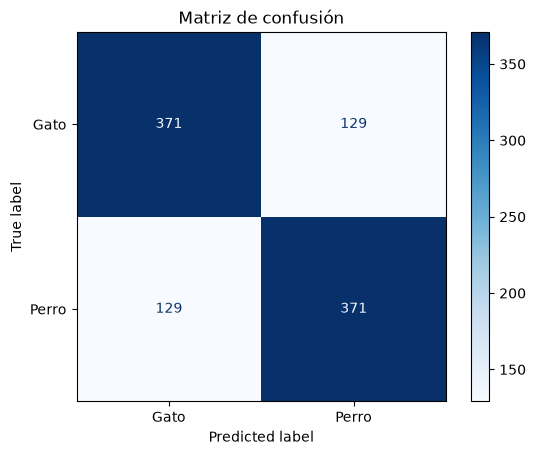

In [30]:
# --- Evaluación sobre test ---

test_loss, test_acc = model.evaluate(X_test_norm, y_test, verbose=0)
print(f"Test loss: {test_loss:.4f} - Test accuracy: {test_acc:.4f}")

# Probabilidades predichas (probabilidad de ser "perro", clase 1)
y_proba = model.predict(X_test_norm, verbose=0).ravel()
y_pred = (y_proba >= 0.5).astype(int)

print("\nReporte de clasificación:\n")
print(classification_report(y_test, y_pred, target_names=["Gato", "Perro"]))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Gato", "Perro"])
disp.plot(cmap="Blues")
plt.title("Matriz de confusión")
plt.show()

### Ejercicio 5

Seleccionamos, de cada clase, el 10% de imágenes peor clasificadas: aquellas mal clasificadas con **mayor confianza** de pertenecer a la clase errónea (es decir, perros clasificados como gatos con probabilidad de perro muy baja / gatos clasificados como perros con probabilidad de perro muy alta).

In [31]:
# --- Selección de las imágenes más "difíciles" ---

df_resultados = pd.DataFrame({
    "filename": files_test,
    "y_true": y_test,
    "y_pred": y_pred,
    "proba_perro": y_proba,
})

# Gatos (clase 0) mal clasificados como perro (pred=1): cuanto mayor la proba_perro, más "seguro" se equivoca el modelo
mask_gatos_mal = (df_resultados["y_true"] == 0) & (df_resultados["y_pred"] == 1)
gatos_mal = df_resultados[mask_gatos_mal].sort_values("proba_perro", ascending=False)

# Perros (clase 1) mal clasificados como gato (pred=0): cuanto menor la proba_perro, más "seguro" se equivoca el modelo
mask_perros_mal = (df_resultados["y_true"] == 1) & (df_resultados["y_pred"] == 0)
perros_mal = df_resultados[mask_perros_mal].sort_values("proba_perro", ascending=True)

n_gatos_dificiles = max(1, int(np.ceil(0.10 * (df_resultados["y_true"] == 0).sum())))
n_perros_dificiles = max(1, int(np.ceil(0.10 * (df_resultados["y_true"] == 1).sum())))

gatos_dificiles = gatos_mal.head(n_gatos_dificiles)
perros_dificiles = perros_mal.head(n_perros_dificiles)

imagenes_dificiles = pd.concat([gatos_dificiles, perros_dificiles])
print(f"Gatos difíciles seleccionados: {len(gatos_dificiles)} de {mask_gatos_mal.sum()} mal clasificados")
print(f"Perros difíciles seleccionados: {len(perros_dificiles)} de {mask_perros_mal.sum()} mal clasificados")
imagenes_dificiles

Gatos difíciles seleccionados: 50 de 129 mal clasificados
Perros difíciles seleccionados: 50 de 129 mal clasificados


,filename,y_true,y_pred,proba_perro
337,cat.11793.jpg,0,1,0.957643
297,cat.11661.jpg,0,1,0.940266
61,cat.10882.jpg,0,1,0.922617
472,cat.12234.jpg,0,1,0.922543
229,cat.11462.jpg,0,1,0.916912
...,...,...,...,...
793,dog.9142.jpg,1,0,0.265932
624,dog.8560.jpg,1,0,0.269690
569,dog.8337.jpg,1,0,0.278092
738,dog.8951.jpg,1,0,0.283889


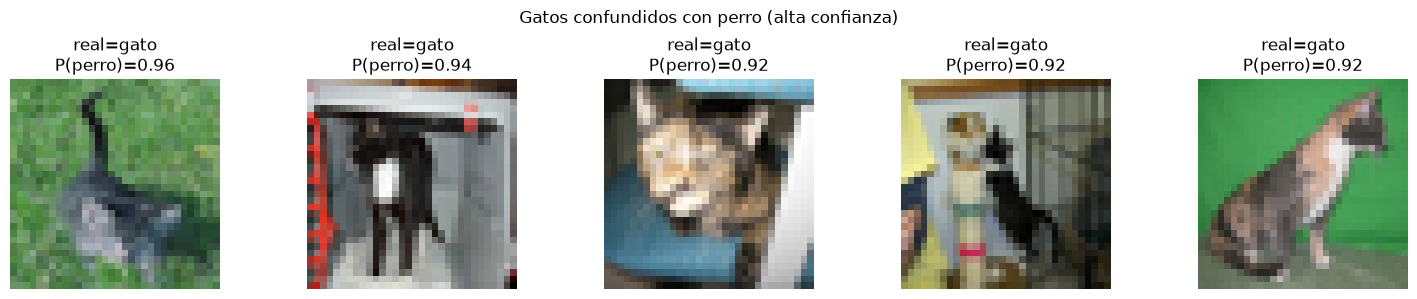

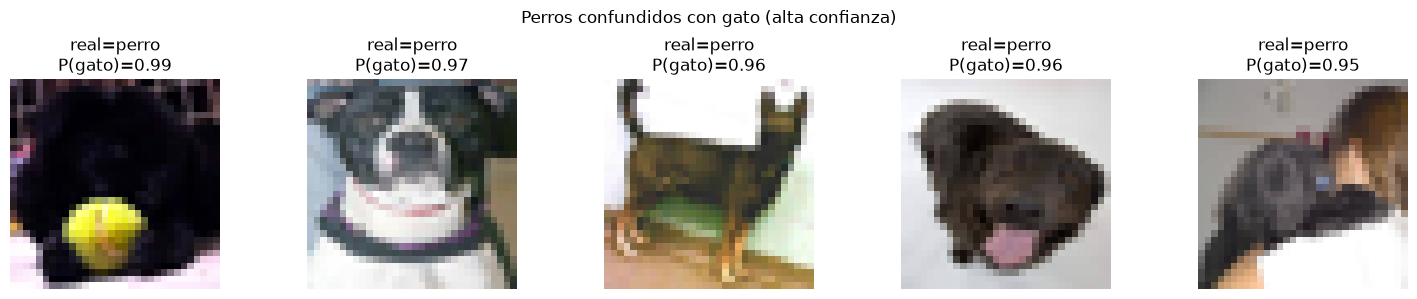

In [39]:
# Visualizamos algunas de las imágenes seleccionadas como más "difíciles"
def mostrar_dificiles(df_subset, titulo, n=5):
    n = min(n, len(df_subset))
    if n == 0:
        print(f"No hay imágenes para: {titulo}")
        return
    fig, axes = plt.subplots(1, n, figsize=(3 * n, 3))
    if n == 1:
        axes = [axes]
    for ax, (_, row) in zip(axes, df_subset.head(n).iterrows()):
        idx = files_test.index(row["filename"])
        ax.imshow(X_test[idx])
        if "con perro" in titulo:
            ax.set_title(f"real={'perro' if row.y_true==1 else 'gato'}\nP(perro)={row.proba_perro:.2f}")
        else:
            ax.set_title(f"real={'perro' if row.y_true==1 else 'gato'}\nP(gato)={1 - row.proba_perro:.2f}")
        ax.axis("off")
    fig.suptitle(titulo)
    plt.tight_layout()
    plt.show()

mostrar_dificiles(gatos_dificiles, "Gatos confundidos con perro (alta confianza)")
mostrar_dificiles(perros_dificiles, "Perros confundidos con gato (alta confianza)")